# Beam impedance of the TESLA cavity

In this tutorial we build the TESLA 9-cell cavity from its cell parameters, put a beam
on its axis and compute its longitudinal beam impedance from 1.0 to 2.9 GHz, below the
cut-off of the beam pipes. The spectrum shows the accelerating π-mode at 1.3 GHz and a
pair of higher-order modes near 2.45 GHz. We read the frequency and R/Q of these three
modes from the impedance alone and compare them with the eigenmodes cavsim2d computes
for the same cavity. Finally we reduce the model and get the same spectrum, frequencies
and R/Q from the reduced model in seconds.

**Prerequisites:** [Add a beam to a solved cavity](beam_on_solved_cavity.ipynb) and
[Build cavities from parameters](../models/parametric_geometries.ipynb). The notebook
runs in about nine minutes.

## 1. Build the cavity

### 1.1 Describe the cells

Each half-cell of an elliptical cavity is `[A, B, a, b, Ri, L, Req]`, in millimetres.
The TESLA cavity has seven identical mid cells and two different end cells, whose iris
radius of 39 mm is also the radius of the beam pipes.

✅ Creating new project 'tesla_beam' at simulations\tesla_beam


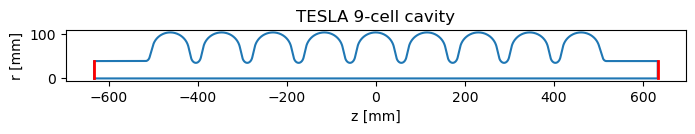

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from cavsim3d.core.em_project import EMProject

tesla_mid = [42, 42, 12, 19, 35, 57.7, 103.353]        # A, B, a, b, Ri, L, Req [mm]
tesla_end_left = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
tesla_end_right = [42, 42, 9, 12.8, 39, 56.815, 103.353]

proj = EMProject(name="tesla_beam", base_dir="./simulations", overwrite=True)
tesla = proj.create_primitive("elliptical_cavity", name="tesla", n_cells=9,
                              mid_cell=tesla_mid, end_cell_left=tesla_end_left,
                              end_cell_right=tesla_end_right, beampipe="both")
tesla.plot_profile()
plt.title("TESLA 9-cell cavity")
plt.show()
# 3D view -- uncomment to open it when you run the notebook:
# tesla.show("geometry")

The profile is revolved about the z axis. The beam pipes are `2 * L` = 115.4 mm long,
and the ports are their end faces.

### 1.2 Add the beam

Without a position, the beam runs on the axis.

In [2]:
proj.add_beam("beam")
proj.beams

{'beam': BeamLine(name='beam', point=(0.0, 0.0, 0.0), beta=1.0, current=True)}

### 1.3 Mesh the cavity

With a beam defined, `generate_mesh()` curves the elements to order 4, so they follow
the curved walls closely. By default netgen also makes the elements smaller where the
walls curve strongly (`curvaturesafety=2`); with fourth-order elements we relax that to
0.5, which keeps the mesh small. Section 3 checks the result against cavsim2d.

In [3]:
mesh = proj.generate_mesh(maxh=0.025, curvaturesafety=0.5)
print(f"{mesh.ne} elements, curve order {tesla.curve_order}")

6291 elements, curve order 4


## 2. Compute the impedance spectrum

### 2.1 Run the sweep

In the 39 mm beam pipes, TM01 propagates above 2.94 GHz. Below, nothing a beam on the
axis excites can leave the cavity, so we sweep from 1.0 to 2.9 GHz, 10 MHz apart. Each
port carries three modes: TE11 in two polarisations, and TM01. We keep no field
solutions (`store_snapshots=False`): 191 of them would fill gigabytes, and we need
only the beam impedance.

In [4]:
t0 = time.time()
res = proj.fds.solve(fmin=1.0, fmax=2.9, nsamples=191, nportmodes=3, order=3,
                     store_snapshots=False)
print(f"solved in {time.time() - t0:.0f} s")


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 6291



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=47.2097, sigma=+1


	port1 mode 1: TE_11 (sin), kc=47.2097, sigma=+1
	port1 mode 2: TM_01, kc=61.6620, sigma=+1
	port2 mode 0: TE_11 (cos), kc=47.2097, sigma=+1
	port2 mode 1: TE_11 (sin), kc=47.2097, sigma=+1
	port2 mode 2: TM_01, kc=61.6620, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 1.0000 - 2.9000 GHz, 191 samples


Global Coupled Solve


  Auto solver: 132720 unknowns, a factorisation needs about 0.8 GB of 23.0 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 496.48s


solved in 498 s


The port modes confirm the cut-offs: TE11 has $k_c$ = 47.2 m⁻¹ (2.25 GHz) and TM01
$k_c$ = 61.7 m⁻¹ (2.94 GHz). A beam on the axis excites only TM0n waves, so TE11 above
2.25 GHz takes nothing away from it.

### 2.2 Plot the spectrum

The beam impedance with every port mode matched, $z_b$, is the beam's own entry of
$\tilde{S}$: `s_tilde_dict["b(1)b(1)"]`. `beam_impedance()` returns
$Z_\parallel = -z_b$. We plot $|z_b|$ on a logarithmic axis and, below it, the sign
that the magnitude hides: Im $Z_\parallel$ on a symmetric logarithmic axis, linear
between −100 and 100 Ω. At the bottom, the R/Q of every monopole mode that cavsim2d
finds in this band with R/Q above 0.1 Ω: cavsim2d solves the same profile in 2D, with
magnetic walls at the pipe ends.

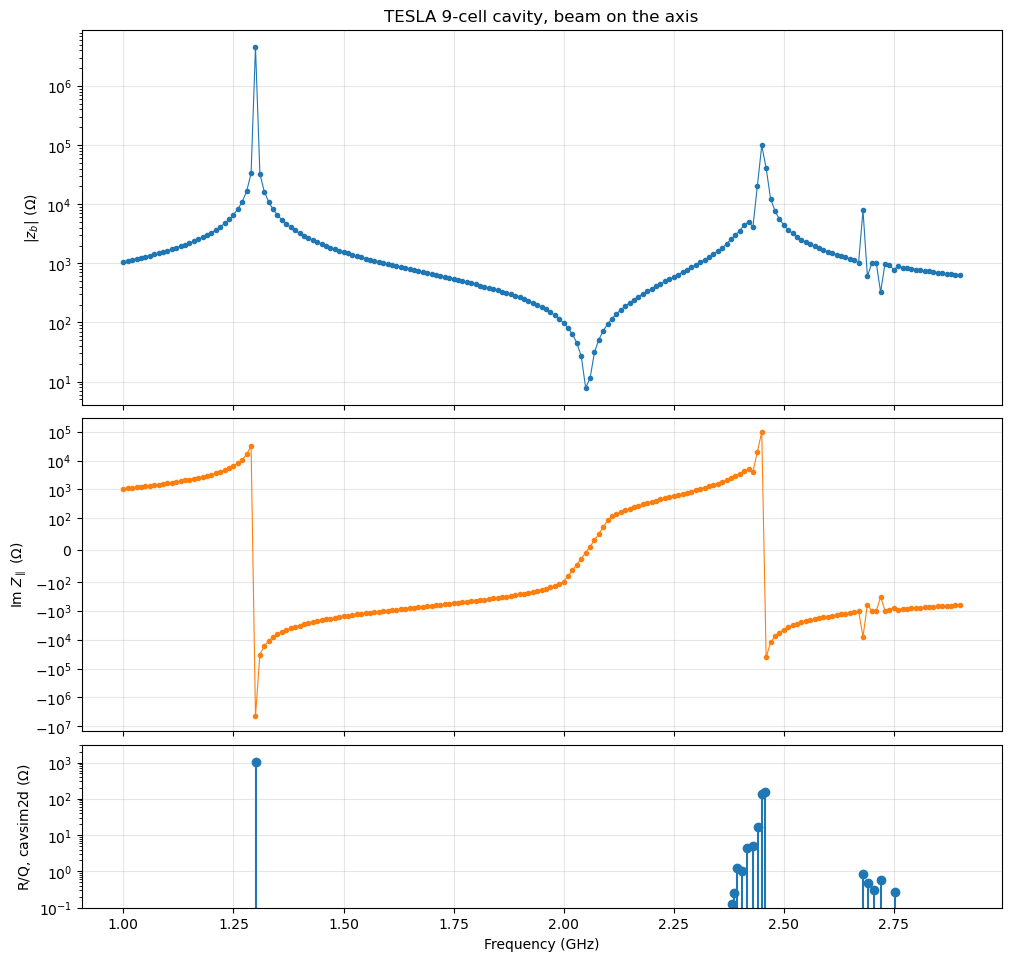

In [5]:
fom = proj.fds.fom
f = fom.frequencies
zb = fom.s_tilde_dict["b(1)b(1)"]       # z_b: beam in, beam voltage out, ports matched
zpar = fom.beam_impedance()             # Z_par = -z_b

# cavsim2d: EllipticalCavity(9, tesla_mid, tesla_end_left, tesla_end_right,
# beampipe="both"), monopole modes, boundary_conditions="mm"
# frequency [MHz], R/Q [Ohm]
cavsim2d = np.array([
    [1300.177, 1011.953],
    [2381.548, 0.126],
    [2386.432, 0.259],
    [2394.288, 1.235],
    [2404.646, 1.056],
    [2416.774, 4.370],
    [2429.618, 4.888],
    [2441.773, 16.557],
    [2451.534, 135.748],
    [2457.321, 155.511],
    [2680.100, 0.835],
    [2690.794, 0.483],
    [2704.912, 0.313],
    [2720.916, 0.586],
    [2751.894, 0.267],
])

fig, (ax_mag, ax_im, ax_rq) = plt.subplots(3, 1, figsize=(10, 9.5), sharex=True,
                                           layout="constrained", height_ratios=[3, 2.5, 1.3])
ax_mag.semilogy(f / 1e9, np.abs(zb), marker="o", ms=3, lw=0.8)
ax_mag.set_ylabel(r"$|z_b|$ ($\Omega$)")
ax_mag.set_title("TESLA 9-cell cavity, beam on the axis")
ax_mag.grid(True, alpha=0.3)
ax_im.plot(f / 1e9, zpar.imag, marker="o", ms=3, lw=0.8, color="C1")
ax_im.set_yscale("symlog", linthresh=100)
ax_im.set_ylabel(r"Im $Z_\parallel$ ($\Omega$)")
ax_im.grid(True, alpha=0.3)
ax_rq.stem(cavsim2d[:, 0] / 1e3, cavsim2d[:, 1], basefmt=" ", bottom=0.1)
ax_rq.set_yscale("log")
ax_rq.set_ylim(0.1, 3e3)
ax_rq.set_ylabel("R/Q, cavsim2d ($\\Omega$)")
ax_rq.set_xlabel("Frequency (GHz)")
ax_rq.grid(True, alpha=0.3)
plt.show()

$|z_b|$ peaks at the resonances and falls to below 10 Ω near 2.05 GHz, where the
impedance changes sign between them. Im $Z_\parallel$ shows what happens at a peak:
the impedance jumps from large positive values (inductive, below) to large negative
ones (capacitive, above), a pole. The strong poles sit where cavsim2d finds a large
R/Q: the π-mode at
1.300 GHz and the pair at 2.452 and 2.457 GHz. The other eight modes of the accelerating
passband (1.277 to 1.299 GHz) have R/Q below 0.1 Ω: a beam at the speed of light
hardly couples to them, and their poles are too narrow to show at this spacing.

### 2.3 Check the real part

In [6]:
ratio = np.abs(zpar.real) / np.abs(zpar)
print(f"|Re Z_par| / |Z_par|: median {np.median(ratio):.1e}, largest {ratio.max():.1e}")
print(f"|Re Z_par|: median {np.median(np.abs(zpar.real)):.2f} Ohm")

|Re Z_par| / |Z_par|: median 5.7e-04, largest 3.1e-02
|Re Z_par|: median 0.48 Ohm


The walls are lossless and no wave leaves, so the real part would be zero; what is left
is discretisation error, a median of 0.06 % of the impedance. It is largest in relative
terms where Im $Z_\parallel$ crosses zero, near 2.05 GHz.

## 3. Compare the strong modes with cavsim2d

### 3.1 Sweep around each strong mode

For each mode with R/Q above 100 Ω we sweep 13 frequencies within ±0.03 % of cavsim2d's
frequency. `beam_impedance(ports="open")` reads the impedance with every port mode
open-circuited, which puts the same magnetic walls at the port faces as cavsim2d has.

In [7]:
strong = cavsim2d[cavsim2d[:, 1] > 100]
zooms = []
for f_n, rq_n in strong:
    proj.fds.solve(fmin=f_n * (1 - 3e-4) / 1e3, fmax=f_n * (1 + 3e-4) / 1e3, nsamples=13,
                   nportmodes=3, order=3, store_snapshots=False, verbose=False)
    zooms.append((proj.fds.fom.frequencies.copy(),
                  proj.fds.fom.beam_impedance(ports="open")))


FDS Solve: 1.2998 - 1.3006 GHz, 13 samples


Global Coupled Solve


  Auto solver: 132720 unknowns, a factorisation needs about 0.8 GB of 20.4 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 30.31s



FDS Solve: 2.4508 - 2.4523 GHz, 13 samples


Global Coupled Solve


  Auto solver: 132720 unknowns, a factorisation needs about 0.8 GB of 21.3 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 30.77s



FDS Solve: 2.4566 - 2.4581 GHz, 13 samples


Global Coupled Solve


  Auto solver: 132720 unknowns, a factorisation needs about 0.8 GB of 21.3 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 35.08s


### 3.2 Fit each pole

Near a pole at $f_0$, with $u = f/f_n - 1$ the detuning from cavsim2d's frequency $f_n$,

$$\mathrm{Im}\,Z_\parallel = \frac{A}{u_0 - u} + b_0 + b_1 u,
\qquad \frac{R}{Q} = \frac{4A}{1 + u_0},$$

the pole of the mode ($f_0 = f_n(1 + u_0)$) on the slowly changing share of the other
modes. Multiplied by $u_0 - u$, the model is linear in $u_0$, $A + b_0 u_0$,
$b_1 u_0 - b_0$ and $b_1$, so one least-squares solve finds them.

In [8]:
fits = []
print(f"{'f0 [MHz]':>10} {'cavsim2d':>10} {'diff':>9}   {'R/Q [Ohm]':>10} {'cavsim2d':>9} {'diff':>8}")
for (f_n, rq_n), (f_zoom, z_zoom) in zip(strong, zooms):
    u = f_zoom / (f_n * 1e6) - 1
    y = z_zoom.imag
    M = np.column_stack([y, -np.ones_like(u), -u, u ** 2])
    (u0, c0, c1, b1), *_ = np.linalg.lstsq(M, y * u, rcond=None)
    b0 = b1 * u0 - c1
    A = c0 - b0 * u0
    fits.append((u0, A, b0, b1))
    f0, rq = f_n * (1 + u0), 4 * A / (1 + u0)
    print(f"{f0:10.3f} {f_n:10.3f} {u0 * 100:+8.4f}%   {rq:10.2f} {rq_n:9.2f} "
          f"{(rq / rq_n - 1) * 100:+7.2f}%")

  f0 [MHz]   cavsim2d      diff    R/Q [Ohm]  cavsim2d     diff
  1299.929   1300.177  -0.0191%      1011.00   1011.95   -0.09%
  2450.975   2451.534  -0.0228%       136.36    135.75   +0.45%
  2456.867   2457.321  -0.0185%       154.80    155.51   -0.46%


All three frequencies are about 0.02 % below cavsim2d's, and the R/Q values agree with
cavsim2d's to 0.5 %: for the π-mode, 1011.0 Ω against 1011.95 Ω, read from the beam
impedance without solving an eigenproblem.

### 3.3 Plot the fits

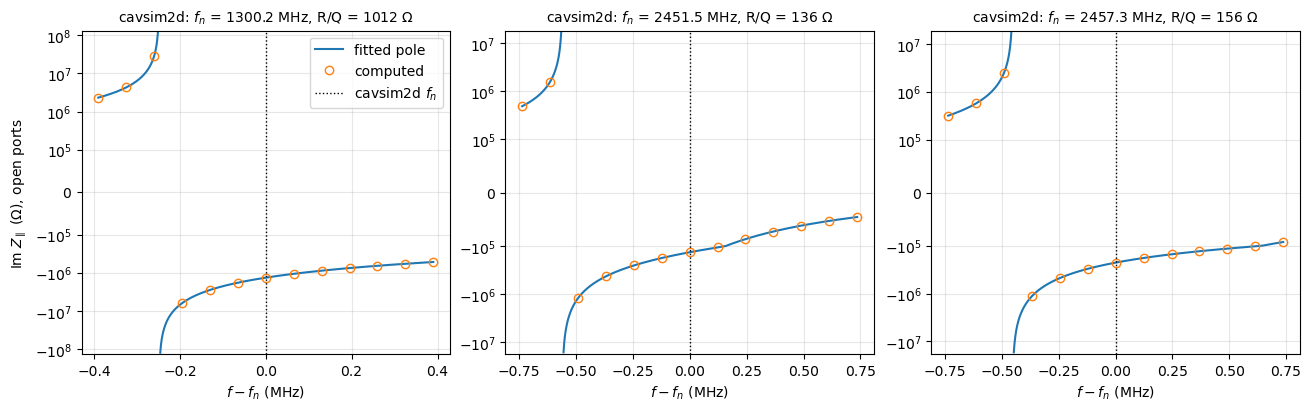

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
for ax, (f_n, rq_n), (f_zoom, z_zoom), (u0, A, b0, b1) in zip(axs, strong, zooms, fits):
    u_line = np.linspace(-3e-4, 3e-4, 2001)
    z_line = A / (u0 - u_line) + b0 + b1 * u_line
    z_line[np.abs(u_line - u0) < 2e-6] = np.nan
    ax.plot(f_n * u_line, z_line, label="fitted pole")
    ax.plot(f_zoom / 1e6 - f_n, z_zoom.imag, lw=0, marker="o", mfc="none", label="computed")
    ax.axvline(0, color="k", ls=":", lw=1, label="cavsim2d $f_n$")
    ax.set_yscale("symlog", linthresh=1e5)
    ax.set_xlabel("$f - f_n$ (MHz)")
    ax.set_title(f"cavsim2d: $f_n$ = {f_n:.1f} MHz, R/Q = {rq_n:.0f} $\\Omega$", fontsize=10)
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel(r"Im $Z_\parallel$ ($\Omega$), open ports")
axs[0].legend()
plt.show()

Every computed point lies on its fitted pole. Each pole sits 0.25 to 0.56 MHz below
cavsim2d's frequency, left of the dotted line.

## 4. Reduce the model

The full-order sweep of section 2 took six minutes for 191 frequencies. A reduced model
gives the spectrum at any frequency of the band in seconds, built from fewer full-order
samples.

### 4.1 Sweep with field snapshots

A reduced model is built from field solutions, which `solve()` keeps by default. The
beam's phase runs along the 1.27 m cavity and repeats every $c/L$ = 237 MHz, so the
samples must lie closer than half of that: we take 39 samples, 50 MHz apart.

In [10]:
t0 = time.time()
proj.fds.solve(fmin=1.0, fmax=2.9, nsamples=39, nportmodes=3, order=3)
print(f"solved in {time.time() - t0:.0f} s")


FDS Solve: 1.0000 - 2.9000 GHz, 39 samples


Global Coupled Solve


  Auto solver: 132720 unknowns, a factorisation needs about 0.8 GB of 21.4 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 85.96s


solved in 87 s


Besides the field solutions, the solve stores the beam's data at the frequencies where
the reduced model interpolates the beam's phase.

### 4.2 Reduce

In [11]:
rom = proj.fds.fom.reduce(tol=1e-8)
print(f"{rom.total_dofs} unknowns -> {rom.reduced_dimensions['global']}")

Model Order Reduction


Reduction complete: 132720 -> 205 DOFs (99.8% compression)


132720 unknowns -> 205


One basis of 205 vectors serves the six port modes and the beam.

### 4.3 Compare with the full-order spectrum

We solve the reduced model at the 191 frequencies of section 2, measure the difference,
and then sweep the band at 1 MHz spacing.


ROM Solve: 1.0000 - 2.9000 GHz, 191 samples


  Solve loop: 0.027s (191 freq points)


  Beam columns: 0.059s


|z_b| relative difference: median 2.3e-07, largest 3.6e-03 at 2.72 GHz



ROM Solve: 1.0000 - 2.9000 GHz, 1901 samples


  Solve loop: 0.116s (1901 freq points)


  Beam columns: 0.383s


1901 frequencies in 0.8 s


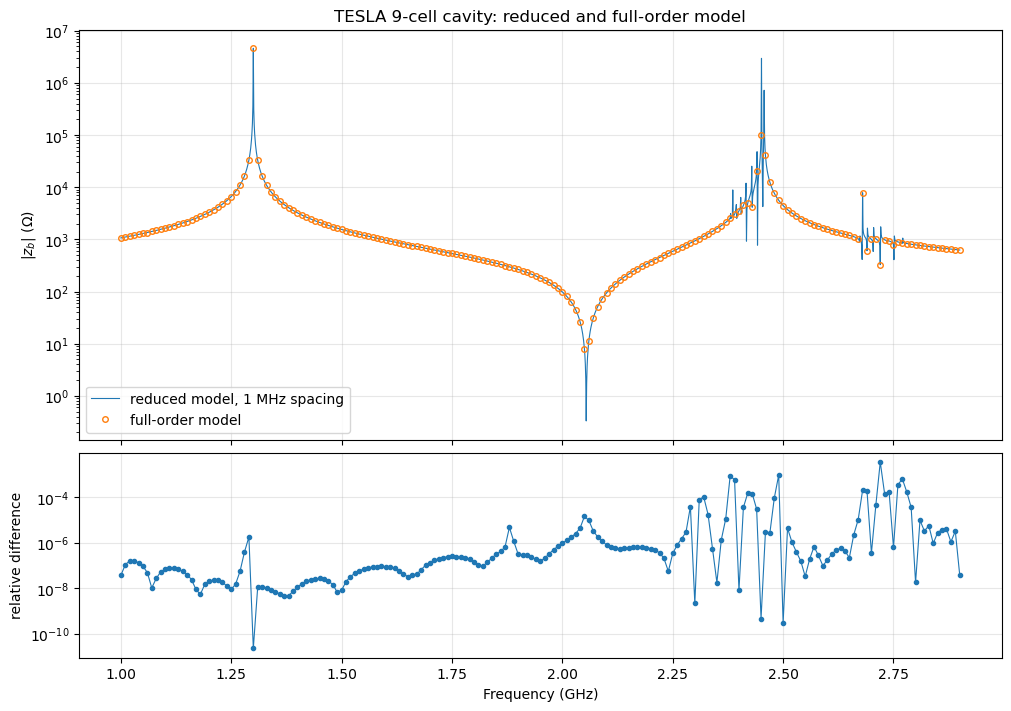

In [12]:
rom.solve(fmin=1.0, fmax=2.9, nsamples=191)
zb_rom = rom.s_tilde_dict["b(1)b(1)"]
rel = np.abs(zb_rom - zb) / np.abs(zb)
print(f"|z_b| relative difference: median {np.median(rel):.1e}, largest {rel.max():.1e} "
      f"at {f[np.argmax(rel)] / 1e9:.2f} GHz")

t0 = time.time()
rom.solve(fmin=1.0, fmax=2.9, nsamples=1901)
print(f"1901 frequencies in {time.time() - t0:.1f} s")

fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained",
                                 height_ratios=[2, 1])
ax.semilogy(rom.frequencies / 1e9, np.abs(rom.s_tilde_dict["b(1)b(1)"]), lw=0.8,
            label="reduced model, 1 MHz spacing")
ax.semilogy(f / 1e9, np.abs(zb), lw=0, marker="o", mfc="none", ms=4,
            label="full-order model")
ax.set_ylabel(r"$|z_b|$ ($\Omega$)")
ax.set_title("TESLA 9-cell cavity: reduced and full-order model")
ax.grid(True, alpha=0.3)
ax.legend()
ax_err.semilogy(f / 1e9, rel, marker="o", ms=3, lw=0.8)
ax_err.set_ylabel("relative difference")
ax_err.set_xlabel("Frequency (GHz)")
ax_err.grid(True, alpha=0.3)
plt.show()

At the 191 frequencies of section 2 the reduced model reproduces $z_b$ with a median
difference of $2.3\cdot10^{-7}$. The largest, $3.6\cdot10^{-3}$ at 2.72 GHz, lies next to a
pole, where the impedance changes fastest; above 2.25 GHz, where TE11 propagates and the
modes crowd, the differences reach $10^{-3}$. The 1901 frequencies take about a second, against six
minutes for the 191 full-order samples.

The 1 MHz sweep also shows the narrow poles of nine weaker modes between 2.38 and
2.72 GHz, beside the two strong ones; the 10 MHz grid caught only the one at 2.68 GHz.
Each lies within 1 MHz of a frequency in cavsim2d's list, with R/Q from 0.26 to 17 Ω.

### 4.4 Fit the strong poles from the reduced model

The same 13 frequencies around each strong mode as in section 3.1, now from the reduced
model, and the same fit.

In [13]:
rows = []
for (f_n, rq_n), (u0_fom, A_fom, _b0, _b1) in zip(strong, fits):
    t0 = time.time()
    rom.solve(fmin=f_n * (1 - 3e-4) / 1e3, fmax=f_n * (1 + 3e-4) / 1e3, nsamples=13,
              verbose=False)
    t_sweep = time.time() - t0
    u = rom.frequencies / (f_n * 1e6) - 1
    y = rom.beam_impedance(ports="open").imag
    M = np.column_stack([y, -np.ones_like(u), -u, u ** 2])
    (u0, c0, c1, b1), *_ = np.linalg.lstsq(M, y * u, rcond=None)
    b0 = b1 * u0 - c1
    A = c0 - b0 * u0
    rows.append((f_n * (1 + u0), 4 * A / (1 + u0), f_n * (1 + u0_fom),
                 4 * A_fom / (1 + u0_fom), t_sweep))

print(f"{'f0 [MHz]':>10} {'full order':>11} {'diff':>9}   {'R/Q [Ohm]':>10} {'full order':>11} "
      f"{'diff':>9}   sweep")
for f0, rq, f0_fom, rq_fom, t_sweep in rows:
    print(f"{f0:10.3f} {f0_fom:11.3f} {f0 / f0_fom - 1:+9.1e}   {rq:10.2f} {rq_fom:11.2f} "
          f"{rq / rq_fom - 1:+9.1e}   {t_sweep * 1e3:.0f} ms")


ROM Solve: 1.2998 - 1.3006 GHz, 13 samples


  Solve loop: 0.017s (13 freq points)


  Beam columns: 0.025s



ROM Solve: 2.4508 - 2.4523 GHz, 13 samples


  Solve loop: 0.011s (13 freq points)


  Beam columns: 0.016s



ROM Solve: 2.4566 - 2.4581 GHz, 13 samples


  Solve loop: 0.014s (13 freq points)


  Beam columns: 0.021s


  f0 [MHz]  full order      diff    R/Q [Ohm]  full order      diff   sweep
  1299.929    1299.929  -1.2e-15      1011.00     1011.00  -1.1e-10   93 ms
  2450.975    2450.975  +1.3e-11       136.36      136.36  -4.2e-07   70 ms
  2456.867    2456.867  +2.9e-10       154.80      154.80  -2.1e-06   76 ms


The reduced model gives the frequencies and R/Q of the full-order fits of section 3:
the frequencies agree to $3\cdot10^{-10}$, the R/Q to $2\cdot10^{-6}$. Each
13-frequency sweep takes about 0.1 s, its results saved included, against 25 s for a
full-order sweep.

## What we did

We built the TESLA 9-cell cavity from its cell parameters, put a beam on its axis,
computed the beam impedance from 1.0 to 2.9 GHz in one sweep, and found the π-mode and
the pair of higher-order modes near 2.45 GHz as its strong poles. Fitting each pole gave
the mode's frequency and R/Q from the beam impedance alone, within 0.02 % and 0.5 % of
cavsim2d's eigenmodes. A reduced model built from 39 full-order samples gave the same
spectrum at 1 MHz spacing in seconds, and the same frequencies and R/Q.

**Next:** [A module of two TESLA cavities](tesla_module.ipynb).

**Background:** [Beam excitation](../../theory/beam.md), §9.7 for the beam impedance
with open ports; [Model order reduction with the beam](../../theory/beam_reduction.md).